### SARIMAX
AR(p): model uses its p past values 
I(d): differencing d times to remove the trend
MA(q): model uses past forecast errors
S(P, D, Q, s): seasonal lags
X: exogenous variables 

SARIMAX model for a sample client. Alternative approach is to cluster similar clients and fit one per cluster. 

### 1. Loading and preparing data
Selecting one random client. 

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import random 
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [20]:
print("Loading processed data...")
df_long = pd.read_parquet('../Datasets/processed_electricity_data.parquet')

# Select a random client for modeling
random.seed(42)
all_clients = sorted(df_long['ClientID'].unique().tolist())

sample_client = random.choice(all_clients)

print(f"Filtering data for client {sample_client}")
df_sample = df_long[df_long['ClientID'] == sample_client].copy()

# Make time stamps index with 15 min frequency
df_sample = df_long[df_long['ClientID'] == sample_client].copy()
df_sample = df_sample.set_index('Date')
df_sample.index = pd.to_datetime(df_sample.index)
df_sample = df_sample.sort_index()
df_sample = df_sample.asfreq("15T")

Loading processed data...
Filtering data for client MT_328


In [21]:
# y is the target variable, exog are the features we will use for modeling
y = df_sample['Consumption']
exog = df_sample[[
    'Weekday', 
    'Hour', 
    'Is_Weekend', 
    'Is_Holiday',
    'Temp_National_Avg', 
    'HDH', 
    'CDH',
    'Lag_15min', 
    'Lag_24h', 
    'Rolling_Mean_4h'
]].astype(float)

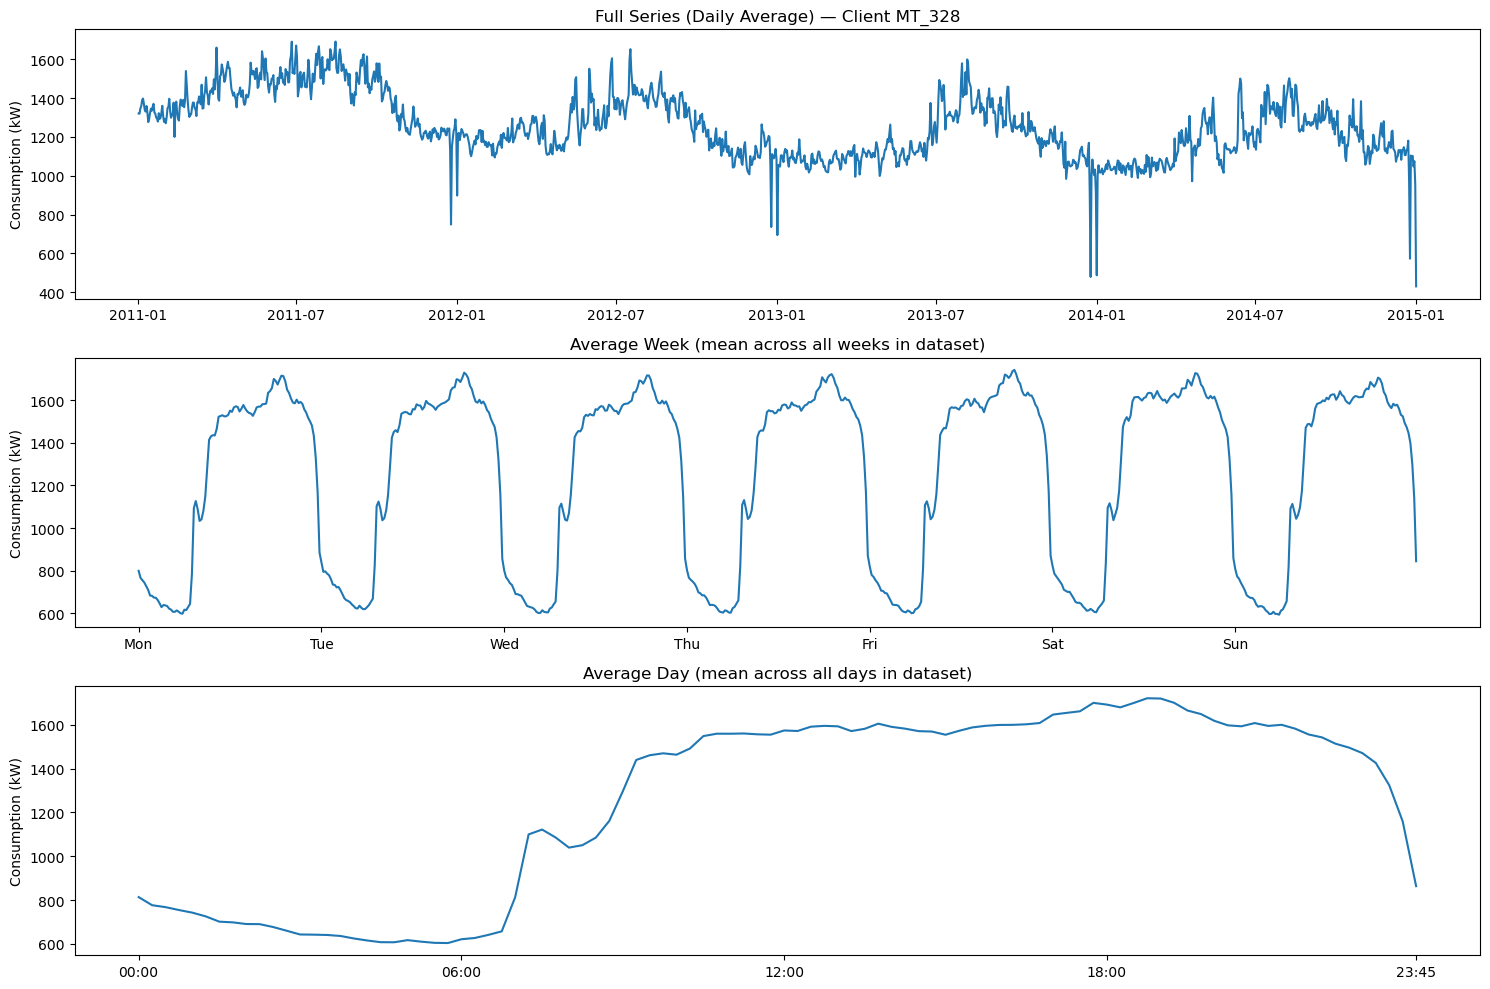

In [22]:
# Data vis for selected client
y_with_features = y.to_frame()
y_with_features['dayofweek'] = y.index.dayofweek
y_with_features['time_of_day'] = y.index.hour * 4 + y.index.minute // 15

average_week = y_with_features.groupby(['dayofweek', 'time_of_day'])['Consumption'].mean()
average_day  = y_with_features.groupby('time_of_day')['Consumption'].mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Full time series of daily average
axes[0].plot(y.resample('D').mean())
axes[0].set_title(f"Full Series (Daily Average) — Client {sample_client}")
axes[0].set_ylabel("Consumption (kW)")

# Average week
axes[1].plot(average_week.values)
axes[1].set_title("Average Week (mean across all weeks in dataset)")
axes[1].set_xticks([i * 96 for i in range(7)])
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_ylabel("Consumption (kW)")

# Average day
axes[2].plot(average_day.values)
axes[2].set_title("Average Day (mean across all days in dataset)")
axes[2].set_xticks([0, 24, 48, 72, 95])
axes[2].set_xticklabels(['00:00', '06:00', '12:00', '18:00', '23:45'])
axes[2].set_ylabel("Consumption (kW)")

plt.tight_layout()
plt.show()

### Seasonality 
In this section we decompose the time series into its trend, seasonal and residual components. Then we conduct an ADF test to see whether the mean drifts.
We can observe seasonality at the daily, weekly and yearly level.

We pick the most granular cycle which is the daily one s=96. 


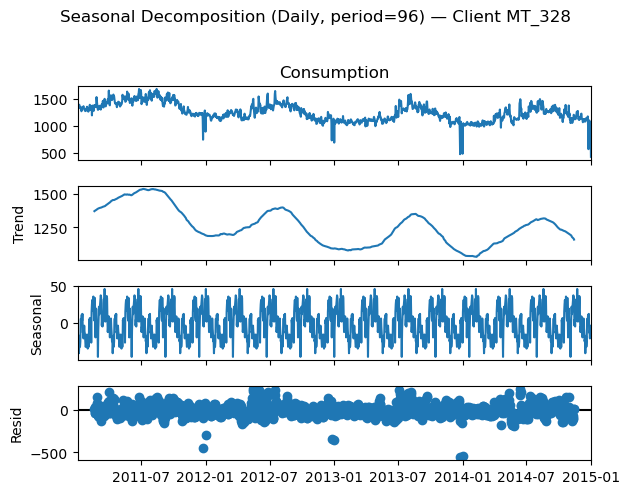

In [23]:
# Resample to daily average to make decomposition readable
y_daily = y.resample('D').mean()

# Decompose into trend + seasonality + residual
# Use period=96 for daily seasonality (since we're at 15-minute frequency, 96 intervals per day)
decomposition = seasonal_decompose(y_daily, model="additive", period=96)
decomposition.plot()
plt.suptitle(f"Seasonal Decomposition (Daily, period=96) — Client {sample_client}", y=1.02)
plt.tight_layout()
plt.show()

In the raw electricity consumption we can see the overall level stays fairly consistent across the 4 years with some sharp dips (outages?). 

The Trend subplot shows the long-term movement after removing daily seasonality patterns. Clearly we can still observe a yearly seasonal component in the data. 

In the seasonal plot, we can see the repeating daily cycle. The pattern is consistent throughout the 4 years.  

The residuals represent the remaining variation in the time series after account for the trend and the seasonal component. The bulk of the points show no discernible pattern and are clustered around 0, however we see that every 6 months there are a few large that are outliers in the data.

In [24]:
# The ADF test

def adf_test(series, name="Series"):
    result = adfuller(series.dropna())
    print(f"\n{'='*50}")
    print(f"ADF Test: {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    if result[1] < 0.05:
        print("Stationary, no differencing needed (d=0)")
    else:
        print("Non-stationary — consider differencing (d=1)")

adf_test(df_sample['Consumption'], f"Electricity Consumption — Client {sample_client}")


ADF Test: Electricity Consumption — Client MT_328
  ADF Statistic : -19.5220
  p-value       : 0.0000
Stationary, no differencing needed (d=0)


### ACF and PACF plots
ACF plots shows the correlation with past values. 
The PACF plot shows the direct correltion with past values, removing the influence of intermediate lags. 
They help us manually select the SARIMAX model parameters. 

The ACF plot shows slow sinusoidal decay confirming the seasonal patterns we observed previously and indicating the MA component is weak or absent. There is no clean cutoff point to read q from.  

The PACF plot shows a very strong spike at lag 1, then drops immediately to near 0 for all other lags. Thus, we should choose AR p = 1 (after accounting for lag 1, no other past values add meaningful information).

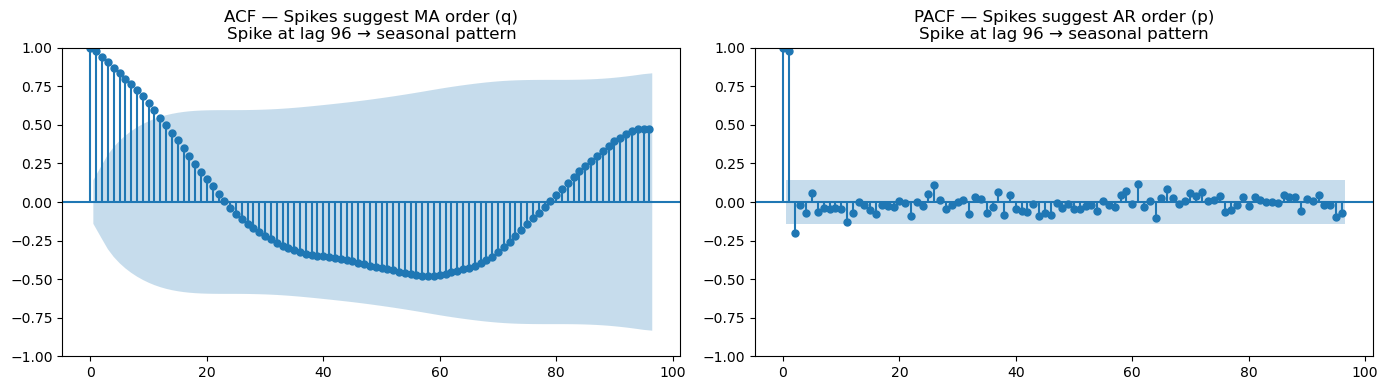

In [25]:
# Plotting ACF and PACF to identify AR and MA orders

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y_sample, lags=96, ax=axes[0])  
axes[0].set_title("ACF — Spikes suggest MA order (q)\nSpike at lag 96 → seasonal pattern")

plot_pacf(y_sample, lags=96, ax=axes[1])
axes[1].set_title("PACF — Spikes suggest AR order (p)\nSpike at lag 96 → seasonal pattern")

plt.tight_layout()
plt.show()

In [26]:
# Based on ACF/PACF analysis of sampled client
p, d, q    = 1, 0, 1
P, D, Q, s = 1, 0, 1, 96

print(f"Using SARIMAX({p},{d},{q})({P},{D},{Q},{s})")


Using SARIMAX(1,0,1)(1,0,1,96)


### Fitting the model
Parameter selction: 
Three approaches were considered for selecting the SARIMAX parameters (p, d, q, P, D, Q, s). The first approach involved running auto_arima on the full 15-minute resolution data, which was immediately infeasible due to memory errors caused by the large dataset size (~140,000 rows per client) combined with a seasonal period of s=96. 
The second approach involved downsampling to hourly data s=24 before running auto_arima, which reduced the dataset size but still resulted in memory errors and excessively long runtimes even on a 6-month subset. 
The third approach was adopted: parameters were selected manually by inspecting the ACF and PACF plots. 

Fitting the model: 
Fitting SARIMAX proved computationally expensive due to the combination of high-frequency 15-minute data and a large seasonal period of s=96. Attempts with 6 months of data exceeded 20 minutes before being interrupted. My solution was to explicitly specify a 2-month window, yielding ~5,755 training rows, which still didn't work.

In [31]:
# Use a fixed 2-month window within data range
df_sample_small = df_sample['2014-01-01':'2014-03-01']

print(f"Sample size : {len(df_sample_small)}")  # should be ~5760

y_train    = df_sample_small['Consumption'].iloc[:-FORECAST_HORIZON]
y_test     = df_sample_small['Consumption'].iloc[-FORECAST_HORIZON:]
exog_train = df_sample_small[[
    'Weekday', 'Hour', 'Is_Weekend', 'Is_Holiday',
    'Temp_National_Avg', 'HDH', 'CDH',
    'Lag_15min', 'Lag_24h', 'Rolling_Mean_4h'
]].astype(float).iloc[:-FORECAST_HORIZON]
exog_test  = df_sample_small[[
    'Weekday', 'Hour', 'Is_Weekend', 'Is_Holiday',
    'Temp_National_Avg', 'HDH', 'CDH',
    'Lag_15min', 'Lag_24h', 'Rolling_Mean_4h'
]].astype(float).iloc[-FORECAST_HORIZON:]

print(f"Train size : {len(y_train)}")

model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)
result = model.fit(disp=False)
print(result.summary())

Sample size : 5760
Train size : 5755


KeyboardInterrupt: 